# A Hybrid Question Answering System over MOOC Catalogs: Combining Ontology-Based Retrieval with Retrieval-Augmented Generation (RAG)

### Project Overview

This project presents a hybrid Question Answering (QA) system for Massive Open Online Course (MOOC) catalogs. The system combines two complementary approaches:

1. **Ontology-Based Retrieval** using RDF graphs and SPARQL queries to represent and retrieve structured knowledge.
2. **Retrieval-Augmented Generation (RAG)** using transformer-based embeddings and vector similarity search to retrieve semantically relevant information from unstructured course descriptions.

The proposed architecture integrates both components through a fusion layer, enabling the system to answer complex user questions with both semantic relevance and factual consistency.

### Dataset

The project uses the Coursera Course Dataset from HuggingFace, containing approximately 6,500 course profiles with structured metadata and unstructured textual descriptions.

### Objectives

- Build an ontology representing courses, instructors, organizations, and course levels.
- Construct a semantic retrieval system using sentence embeddings and FAISS.
- Combine symbolic and neural approaches in a hybrid QA pipeline.
- Evaluate the performance of the hybrid system against standalone ontology-based and RAG-based approaches.

### Technologies Used

- Python
- Pandas
- RDFLib
- SPARQL
- Sentence Transformers
- FAISS
- Scikit-learn
- Matplotlib

---

# 1. Introduction and Motivation

Massive Open Online Course (MOOC) platforms such as Coursera provide thousands of courses across different subjects, institutions, and difficulty levels. As the number of available courses continues to grow, users often face difficulties in finding the most relevant courses that match their learning goals.

Traditional search systems mainly rely on keyword matching. While these systems can retrieve documents containing specific words, they often fail to understand the actual meaning or intent behind a user's question. For example, a user searching for "courses about neural networks for beginners" may not receive the most relevant results if the exact keywords do not appear in the course title.

Recent advances in Artificial Intelligence have introduced Retrieval-Augmented Generation (RAG), which uses vector embeddings to retrieve information based on semantic similarity rather than exact keyword matches. RAG systems are effective at understanding natural language queries and retrieving contextually relevant information. However, they do not inherently enforce structured relationships or guarantee factual correctness.

On the other hand, ontologies provide a structured representation of knowledge through entities, relationships, and formal semantics. Ontology-based systems can accurately answer factual questions such as identifying course instructors, organizations, or difficulty levels. However, they are less effective when dealing with open-ended natural language queries and unstructured textual content.

To address these limitations, this project proposes a Hybrid Semantic Question Answering System that combines:

- Ontology-Based Retrieval (Declarative Semantics)
- Retrieval-Augmented Generation (Distributional Semantics)

The ontology component is responsible for representing and querying structured course information using RDF triples and SPARQL queries. The RAG component retrieves semantically relevant course descriptions using transformer-based embeddings and vector similarity search. A fusion layer combines the outputs of both components to provide answers that are both contextually relevant and factually accurate.

## Research Objectives

The main objectives of this project are:

1. Construct an ontology representing courses, instructors, organizations, and course levels.
2. Build a semantic retrieval system using transformer embeddings and FAISS.
3. Develop a hybrid question answering pipeline that combines symbolic and neural approaches.
4. Compare the performance of:
   - Ontology-Based Retrieval
   - RAG-Based Retrieval
   - Hybrid Ontology + RAG Retrieval
5. Evaluate the effectiveness of the proposed approach using standard information retrieval metrics.

## Expected Contribution

This project demonstrates how symbolic knowledge representation and neural retrieval methods can be integrated into a single system. The resulting architecture aims to improve both semantic understanding and factual reliability when answering user questions about online courses.

# 2. System Architecture

The proposed system follows a hybrid architecture that combines two independent but complementary pipelines: Ontology-Based Retrieval and Retrieval-Augmented Generation (RAG). Both pipelines process the same input data but from different semantic perspectives and are later merged through a fusion layer.

## Overall Workflow

1. The user submits a natural language question.
2. The query is processed in parallel by two modules:
   - Ontology-Based Retrieval (Symbolic Reasoning)
   - RAG-Based Retrieval (Semantic Search)
3. The results from both systems are combined in a Fusion Layer.
4. The final answer is generated using both structured and unstructured knowledge.

## Ontology-Based Pipeline (Declarative Semantics)

- Uses RDF (Resource Description Framework) to represent structured data.
- Defines entities such as:
  - Course
  - Instructor
  - Organization
  - Level
- Relationships are modeled using predicates such as:
  - taughtBy
  - offeredBy
  - hasLevel
- SPARQL queries are used to retrieve exact factual information.

This layer ensures:
- High factual accuracy
- Structured reasoning
- Explainability of results

## RAG-Based Pipeline (Distributional Semantics)

- Uses transformer-based embeddings (Sentence-BERT).
- Converts course descriptions into dense vector representations.
- Stores embeddings in a FAISS vector database.
- Retrieves semantically similar courses based on query similarity.

This layer ensures:
- Understanding of natural language queries
- Flexibility with unstructured text
- Semantic similarity matching

## Fusion Layer

The fusion layer combines outputs from both pipelines:

- RAG retrieves the most relevant course candidates.
- Ontology validates and enriches these candidates using structured facts.
- Final response is generated using both sources.

This hybrid approach ensures:
- Semantic relevance (RAG)
- Factual correctness (Ontology)

## Architecture Diagram

(Refer to the diagram inserted in the previous section or include a rendered diagram here if supported in the notebook environment)

### Install Required Libraries

### Import Libraries

In [1]:
# ==========================================
# Data Processing
# ==========================================
import pandas as pd
import numpy as np
import re
import random
from urllib.parse import quote

# ==========================================
# Dataset
# ==========================================
import datasets
import pyarrow
from datasets import load_dataset

# ==========================================
# RDF / Ontology
# ==========================================
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS

# ==========================================
# Embeddings & Semantic Search
# ==========================================
from sentence_transformers import SentenceTransformer
import faiss

# ==========================================
# Visualization
# ==========================================
import matplotlib.pyplot as plt

# ==========================================
# Utilities
# ==========================================
from tqdm import tqdm

print("All libraries imported successfully.")


All libraries imported successfully.


### Global Configuration

In [2]:
# ==========================================
# Project Configuration
# ==========================================

# Hugging Face Dataset
DATASET_NAME = "azrai99/coursera-course-dataset"

# Embedding Model for RAG
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# Number of documents retrieved by FAISS
TOP_K = 5

# Number of rows to use (None = full dataset)
MAX_ROWS = None

# Random seed for reproducibility
RANDOM_SEED = 42

# Namespace for RDF ontology
BASE_URI = "http://example.org/mooc/"

print("Configuration Loaded")
print(f"Dataset: {DATASET_NAME}")
print(f"Embedding Model: {EMBEDDING_MODEL}")
print(f"Top K: {TOP_K}")
print(f"Base URI: {BASE_URI}")

Configuration Loaded
Dataset: azrai99/coursera-course-dataset
Embedding Model: sentence-transformers/all-MiniLM-L6-v2
Top K: 5
Base URI: http://example.org/mooc/


### Load Dataset

In [3]:
# ==========================================
# Load Coursera Dataset
# ==========================================

dataset = load_dataset(DATASET_NAME)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'title', 'enrolled', 'rating', 'num_reviews', 'Instructor', 'Organization', 'Skills', 'Description', 'Modules/Courses', 'Level', 'Schedule', 'URL', 'Satisfaction Rate'],
        num_rows: 6645
    })
})


### Convert Dataset to Pandas DataFrame

In [4]:
# ==========================================
# Convert to Pandas DataFrame
# ==========================================

df = dataset["train"].to_pandas()

if MAX_ROWS:
    df = df.head(MAX_ROWS)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (6645, 14)


,Unnamed: 0,title,enrolled,rating,num_reviews,Instructor,Organization,Skills,Description,Modules/Courses,Level,Schedule,URL,Satisfaction Rate
0,0,Analytical Solutions to Common Healthcare Prob...,"5,710",4.6,27.0,Brian Paciotti,"University of California, Davis",[],"In this course, we’re going to go over analyti...",4 modules,Intermediate level,10 hours to complete (3 weeks at 3 hours a week),https://www.coursera.org/learn/analytical-solu...,None
1,1,Understanding Einstein: The Special Theory of ...,"170,608",4.9,3061.0,Larry Randles Lagerstrom,Stanford University,[],In this course we will seek to “understand Ein...,8 modules,Beginner level,None,https://www.coursera.org/learn/einstein-relati...,98%
2,2,JavaScript for Beginners Specialization,"37,762",4.7,772.0,William Mead,"University of California, Davis","['web interactivty', 'Jquery', 'Data Manipulat...",This Specialization is intended for the learne...,4 course series,Beginner level,2 months (at 10 hours a week),https://www.coursera.org/specializations/javas...,None
3,3,"Security, Compliance, and Governance for AI So...",Enrollment number not found,Rating not found,2024.0,AWS Instructor,Amazon Web Services,[],This course helps you understand some common i...,1 module,Beginner level,1 hour to complete,https://www.coursera.org/learn/security-compli...,None
4,4,Understanding Fitness Programming,Enrollment number not found,Rating not found,NaN,Casey DeJong,National Academy of Sports Medicine,"['Cardiovascular training', 'Resistance traini...","In this course, you will learn to identify app...",5 modules,Beginner level,27 hours to complete (3 weeks at 9 hours a week),https://www.coursera.org/learn/understanding-f...,None


In [5]:
# ==========================================
# SAFE CLEANING (FIXED FOR YOUR DATASET)
# ==========================================

import numpy as np
import pandas as pd

df = df.copy()

# ------------------------------------------
# 1. Ensure columns exist (safety check)
# ------------------------------------------

required_cols = [
    "rating",
    "num_reviews",
    "enrolled",
    "title",
    "Instructor",
    "Organization",
    "Level",
    "Description",
    "Modules/Courses"
]

for col in required_cols:
    if col not in df.columns:
        df[col] = np.nan

# ------------------------------------------
# 2. Clean text fields
# ------------------------------------------

def clean_text(text):
    if pd.isna(text):
        return ""
    return str(text).replace('"', '').replace("'", "").strip()

for col in ["title", "Instructor", "Organization", "Level"]:
    df[col] = df[col].apply(clean_text)

# ------------------------------------------
# 3. Numeric cleaning (SAFE)
# ------------------------------------------

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["rating"] = df["rating"].fillna(df["rating"].median())

df["num_reviews"] = pd.to_numeric(df["num_reviews"], errors="coerce")
df["num_reviews"] = df["num_reviews"].fillna(0)

df["enrolled"] = df["enrolled"].astype(str).str.replace(",", "")
df["enrolled"] = pd.to_numeric(df["enrolled"], errors="coerce")
df["enrolled"] = df["enrolled"].fillna(df["enrolled"].median())

# ------------------------------------------
# 4. Text fields fill
# ------------------------------------------

df["Description"] = df["Description"].fillna("")
df["Modules/Courses"] = df["Modules/Courses"].fillna("")

# ------------------------------------------
# 5. Final check
# ------------------------------------------

print("✅ CLEANING SUCCESSFUL")
print(df.isnull().sum().head(10))
df.head()

✅ CLEANING SUCCESSFUL
Unnamed: 0         0
title              0
enrolled           0
rating             0
num_reviews        0
Instructor         0
Organization       0
Skills             0
Description        0
Modules/Courses    0
dtype: int64


,Unnamed: 0,title,enrolled,rating,num_reviews,Instructor,Organization,Skills,Description,Modules/Courses,Level,Schedule,URL,Satisfaction Rate
0,0,Analytical Solutions to Common Healthcare Prob...,5710.0,4.6,27.0,Brian Paciotti,"University of California, Davis",[],"In this course, we’re going to go over analyti...",4 modules,Intermediate level,10 hours to complete (3 weeks at 3 hours a week),https://www.coursera.org/learn/analytical-solu...,None
1,1,Understanding Einstein: The Special Theory of ...,170608.0,4.9,3061.0,Larry Randles Lagerstrom,Stanford University,[],In this course we will seek to “understand Ein...,8 modules,Beginner level,None,https://www.coursera.org/learn/einstein-relati...,98%
2,2,JavaScript for Beginners Specialization,37762.0,4.7,772.0,William Mead,"University of California, Davis","['web interactivty', 'Jquery', 'Data Manipulat...",This Specialization is intended for the learne...,4 course series,Beginner level,2 months (at 10 hours a week),https://www.coursera.org/specializations/javas...,None
3,3,"Security, Compliance, and Governance for AI So...",16339.0,4.7,2024.0,AWS Instructor,Amazon Web Services,[],This course helps you understand some common i...,1 module,Beginner level,1 hour to complete,https://www.coursera.org/learn/security-compli...,None
4,4,Understanding Fitness Programming,16339.0,4.7,0.0,Casey DeJong,National Academy of Sports Medicine,"['Cardiovascular training', 'Resistance traini...","In this course, you will learn to identify app...",5 modules,Beginner level,27 hours to complete (3 weeks at 9 hours a week),https://www.coursera.org/learn/understanding-f...,None


### Explore Dataset Structure

In [6]:
# ==========================================
# Dataset Overview
# ==========================================

print("Columns:\n")
for col in df.columns:
    print("-", col)

print("\nShape:", df.shape)

Columns:

- Unnamed: 0
- title
- enrolled
- rating
- num_reviews
- Instructor
- Organization
- Skills
- Description
- Modules/Courses
- Level
- Schedule
- URL
- Satisfaction Rate

Shape: (6645, 14)


### Dataset Information

In [7]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6645 entries, 0 to 6644
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6645 non-null   int64  
 1   title              6645 non-null   object 
 2   enrolled           6645 non-null   float64
 3   rating             6645 non-null   float64
 4   num_reviews        6645 non-null   float64
 5   Instructor         6645 non-null   object 
 6   Organization       6645 non-null   object 
 7   Skills             6645 non-null   object 
 8   Description        6645 non-null   object 
 9   Modules/Courses    6645 non-null   object 
 10  Level              6645 non-null   object 
 11  Schedule           4757 non-null   object 
 12  URL                6645 non-null   object 
 13  Satisfaction Rate  2198 non-null   object 
dtypes: float64(3), int64(1), object(10)
memory usage: 726.9+ KB


### Missing Values Analysis

In [8]:
# ==========================================
# Missing Values Analysis
# ==========================================

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Percentage": (missing_values.values / len(df)) * 100
})

missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

,Column,Missing Values,Percentage
13,Satisfaction Rate,4447,66.922498
11,Schedule,1888,28.412340
2,enrolled,0,0.000000
3,rating,0,0.000000
0,Unnamed: 0,0,0.000000
1,title,0,0.000000
5,Instructor,0,0.000000
4,num_reviews,0,0.000000
6,Organization,0,0.000000
7,Skills,0,0.000000


### Select Relevant Columns

In [9]:
# ==========================================
# Select Relevant Columns
# ==========================================

selected_columns = [
    "title",
    "Instructor",
    "Organization",
    "Level",
    "Description",
    "Modules/Courses"
]

df = df[selected_columns].copy()

print("Selected Columns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

Selected Columns:
['title', 'Instructor', 'Organization', 'Level', 'Description', 'Modules/Courses']

Shape:
(6645, 6)


### Inspect Missing Values in Project Columns

In [10]:
# ==========================================
# Missing Values in Selected Columns
# ==========================================

df.isnull().sum()

title              0
Instructor         0
Organization       0
Level              0
Description        0
Modules/Courses    0
dtype: int64

### Data Cleaning

In [11]:
# ==========================================
# Basic Data Cleaning
# ==========================================

# Remove rows with missing descriptions
df = df.dropna(subset=["Description"])

# Remove rows with missing modules
df = df.dropna(subset=["Modules/Courses"])

# Remove rows with missing instructor
df = df.dropna(subset=["Instructor"])

# Replace missing levels
df["Level"] = df["Level"].fillna("Unknown")

# Remove duplicate courses
df = df.drop_duplicates(subset=["title"])

print("Dataset Shape After Cleaning:")
print(df.shape)

Dataset Shape After Cleaning:
(6599, 6)


### Verify Cleaning

In [12]:
# ==========================================
# Verify Missing Values
# ==========================================

df.isnull().sum()

title              0
Instructor         0
Organization       0
Level              0
Description        0
Modules/Courses    0
dtype: int64

### Dataset Statistics

In [13]:
# ==========================================
# Dataset Statistics
# ==========================================

print(f"Number of Courses      : {df['title'].nunique()}")
print(f"Number of Instructors  : {df['Instructor'].nunique()}")
print(f"Number of Organizations: {df['Organization'].nunique()}")
print(f"Number of Levels       : {df['Level'].nunique()}")

Number of Courses      : 6599
Number of Instructors  : 2522
Number of Organizations: 298
Number of Levels       : 4


### Level Distribution

In [14]:
# ==========================================
# Level Distribution
# ==========================================

df["Level"].value_counts()

Level
Beginner level        3563
Intermediate level    2013
                       772
Advanced level         251
Name: count, dtype: int64

### Visualize Course Levels

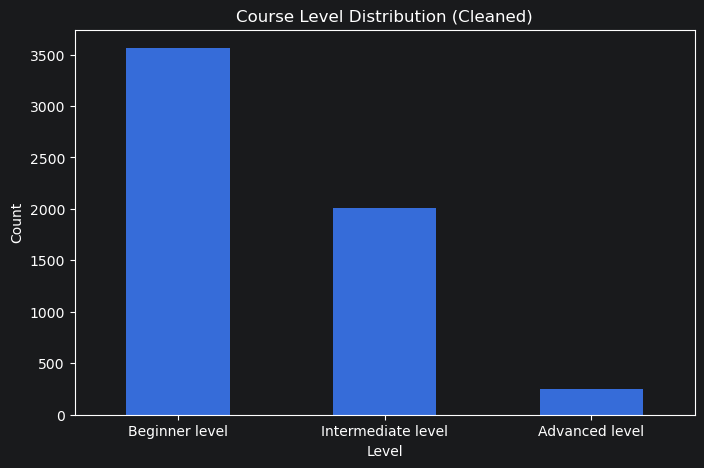

In [15]:
# ==========================================
# Course Level Distribution
# ==========================================

# ------------------------------------------
# KEEP ONLY VALID LEVELS
# ------------------------------------------
df_clean = df[df["Level"].isin([
    "Beginner level",
    "Intermediate level",
    "Advanced level"
])].copy()

# Reset index after filtering
df_clean = df_clean.reset_index(drop=True)

# ------------------------------------------
# REMOVE INVALID / EMPTY LEVEL ROWS
# ------------------------------------------
df_clean = df_clean[df_clean["Level"].notna()]
df_clean = df_clean[df_clean["Level"] != ""]

# ------------------------------------------
# PLOT DISTRIBUTION
# ------------------------------------------
level_counts = df_clean["Level"].value_counts()

plt.figure(figsize=(8,5))
level_counts.plot(kind="bar")

plt.title("Course Level Distribution (Cleaned)")
plt.xlabel("Level")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

### Sample Records

In [16]:
# ==========================================
# Sample Courses
# ==========================================

df_clean.sample(5, random_state=RANDOM_SEED)

,title,Instructor,Organization,Level,Description,Modules/Courses
4072,Deploying the circular economy within organisa...,Pierre-Emmanuel SAINT-ESPRIT,ESSEC Business School,Beginner level,How can companies act in the fight against glo...,4 modules
4881,Game Design and Development 3: 3D Shooter,Brian Winn,Michigan State University,Intermediate level,If you love games and want to learn how to mak...,4 modules
1121,Medical Neuroscience,"Leonard E. White, Ph.D.",Duke University,Advanced level,Medical Neuroscience explores the functional o...,18 modules
561,Get Started with Android App Development,Ramanujam Srinivasan,SkillUp EdTech,Beginner level,"In today's digital age, mobile applications ar...",3 modules
1188,Certified in Cybersecurity Specialization,ISC2 Education & Training,ISC2,Beginner level,Congratulations on your interest in pursuing a...,5 course series


### Create RAG Document Preview

In [17]:
# ==========================================
# Create Combined Text Document
# ==========================================

def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).replace("\n", " ").strip()

df_clean["document"] = (
    "Title: " + df_clean["title"].apply(safe_text) +
    ". " +
    "Description: " + df_clean["Description"].apply(safe_text) +
    ". " +
    "Modules: " + df_clean["Modules/Courses"].apply(safe_text)
)

# ------------------------------------------
# OPTIONAL: Clean double spaces
# ------------------------------------------
df_clean["document"] = df_clean["document"].str.replace(r"\s+", " ", regex=True)

# ------------------------------------------
# Preview
# ------------------------------------------
print(df_clean["document"].iloc[0][:800])

Title: Analytical Solutions to Common Healthcare Problems. Description: In this course, we’re going to go over analytical solutions to common healthcare problems. I will review these business problems and you’ll build out various data structures to organize your data. We’ll then explore ways to group data and categorize medical codes into analytical categories. You will then be able to extract, transform, and load data into data structures required for solving medical problems and be able to also harmonize data from multiple sources. Finally, you will create a data dictionary to communicate the source and value of data. Creating these artifacts of data processes is a key skill when working with healthcare data. In this module, you will explain why comparing healthcare providers with respec


### Ontology Design

The ontology represents structured knowledge extracted from the MOOC dataset.

### Classes

- Course
- Instructor
- Organization
- Level

### Relationships

- taughtBy
- offeredBy
- hasLevel

### Example RDF Triples

Course → taughtBy → Instructor

Course → offeredBy → Organization

Course → hasLevel → Level

The ontology will be implemented using RDFLib and queried using SPARQL.

### Create RDF Graph (Ontology Setup)

In [18]:
# ==========================================
# Ontology Construction (RDF Graph)
# ==========================================

from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS

# Create RDF graph
g = Graph()

# Define namespace
MOOC = Namespace(BASE_URI)

# Bind namespace (for readable output)
g.bind("mooc", MOOC)

print("RDF Graph initialized successfully.")

RDF Graph initialized successfully.


### Define Ontology Schema (Classes + Properties)

In [19]:
# ==========================================
# Define Ontology Schema
# ==========================================

# Classes
Course = MOOC.Course
Instructor = MOOC.Instructor
Organization = MOOC.Organization
Level = MOOC.Level

# Relationships (Predicates)
taughtBy = MOOC.taughtBy
offeredBy = MOOC.offeredBy
hasLevel = MOOC.hasLevel

print("Ontology schema defined.")

Ontology schema defined.


### Helper Function to Clean Text

In [20]:
# ==========================================
# Utility: Clean text for RDF-safe URIs
# ==========================================

def clean_text(text):
    """
    Converts any string into a safe RDF URI component.
    Removes quotes, special characters, extra underscores,
    and normalizes text to lowercase.
    """

    # Handle missing values
    if pd.isna(text):
        return "unknown"

    text = str(text)

    # Remove quotes
    text = text.replace('"', '')
    text = text.replace("'", "")

    # Replace non-alphanumeric characters with underscore
    text = re.sub(r'[^a-zA-Z0-9]', '_', text)

    # Collapse multiple underscores
    text = re.sub(r'_+', '_', text)

    # Remove leading/trailing underscores
    text = text.strip('_')

    # Convert to lowercase
    text = text.lower()

    # Prevent empty URI fragments
    if text == "":
        text = "unknown"

    return text


# ==========================================
# Quick Test
# ==========================================

print(clean_text('Ira "Ike" Levine'))
print(clean_text('Dr. Tim "Dr. T" Chamillard'))
print(clean_text(None))

ira_ike_levine
dr_tim_dr_t_chamillard
unknown


### Populate Ontology (Create RDF Triples)

In [21]:
# ==========================================
# Populate RDF Ontology Graph
# ==========================================

# Extra predicates for useful course facts
hasDescription = MOOC.hasDescription
hasModules = MOOC.hasModules
hasCourseIndex = MOOC.hasCourseIndex

# This dictionary helps us find the RDF URI of a course by title later
course_title_to_uri = {}

for idx, row in df_clean.iterrows():

    # Entities
    course_uri = URIRef(MOOC[f"course_{idx}"])
    instructor_uri = URIRef(MOOC[f"instructor_{clean_text(row['Instructor'])}"])
    org_uri = URIRef(MOOC[f"org_{clean_text(row['Organization'])}"])
    level_uri = URIRef(MOOC[f"level_{clean_text(row['Level'])}"])

    # Save mapping: normalized title -> course URI
    course_title_to_uri[str(row["title"]).lower().strip()] = course_uri

    # Types
    g.add((course_uri, RDF.type, Course))
    g.add((instructor_uri, RDF.type, Instructor))
    g.add((org_uri, RDF.type, Organization))
    g.add((level_uri, RDF.type, Level))

    # Labels
    g.add((course_uri, RDFS.label, Literal(row["title"])))
    g.add((instructor_uri, RDFS.label, Literal(row["Instructor"])))
    g.add((org_uri, RDFS.label, Literal(row["Organization"])))
    g.add((level_uri, RDFS.label, Literal(row["Level"])))

    # Course literals
    g.add((course_uri, hasDescription, Literal(row["Description"])))
    g.add((course_uri, hasModules, Literal(row["Modules/Courses"])))
    g.add((course_uri, hasCourseIndex, Literal(int(idx))))

    # Relations
    g.add((course_uri, taughtBy, instructor_uri))
    g.add((course_uri, offeredBy, org_uri))
    g.add((course_uri, hasLevel, level_uri))

print("Ontology populated successfully.")
print("Total RDF triples:", len(g))


Ontology populated successfully.
Total RDF triples: 51575


In [22]:
# 1. Check how many facts are in the graph
print(len(g))

# 2. Print exactly 3 triples just to see what they look like
for i, (subject, predicate, object) in enumerate(g):
    print(f"Subject: {subject} | Predicate: {predicate} | Object: {object}")
    if i == 4:
        break

51575
Subject: http://example.org/mooc/course_2219 | Predicate: http://www.w3.org/2000/01/rdf-schema#label | Object: Managing and Optimizing SD-Branch Networks
Subject: http://example.org/mooc/course_5684 | Predicate: http://www.w3.org/1999/02/22-rdf-syntax-ns#type | Object: http://example.org/mooc/Course
Subject: http://example.org/mooc/instructor_arun_agrawal | Predicate: http://www.w3.org/2000/01/rdf-schema#label | Object: Arun Agrawal
Subject: http://example.org/mooc/course_1440 | Predicate: http://example.org/mooc/hasDescription | Object: Cloud computing systems today, whether open-source or used inside companies, are built using a common set of core techniques, algorithms, and design philosophies – all centered around distributed systems. Learn about such fundamental distributed computing "concepts" for cloud computing. Some of these concepts include: clouds, MapReduce, key-value/NoSQL stores, classical distributed algorithms, widely-used distributed algorithms, scalability, tren

### Build RAG Documents

In [23]:
# ==========================================
# Build RAG Documents 
# ==========================================

df_clean["document"] = (
    "Title: " + df_clean["title"].astype(str) +
    ". Instructor: " + df_clean["Instructor"].astype(str) +
    ". Organization: " + df_clean["Organization"].astype(str) +
    ". Level: " + df_clean["Level"].astype(str) +
    ". Description: " + df_clean["Description"].astype(str) +
    ". Modules: " + df_clean["Modules/Courses"].astype(str)
)

# Clean extra spaces
df_clean["document"] = df_clean["document"].str.replace(r"\s+", " ", regex=True)

print("RAG documents created successfully.")
print("\nExample document:\n")
print(df_clean["document"].iloc[0][:1200])

RAG documents created successfully.

Example document:

Title: Analytical Solutions to Common Healthcare Problems. Instructor: Brian Paciotti. Organization: University of California, Davis. Level: Intermediate level. Description: In this course, we’re going to go over analytical solutions to common healthcare problems. I will review these business problems and you’ll build out various data structures to organize your data. We’ll then explore ways to group data and categorize medical codes into analytical categories. You will then be able to extract, transform, and load data into data structures required for solving medical problems and be able to also harmonize data from multiple sources. Finally, you will create a data dictionary to communicate the source and value of data. Creating these artifacts of data processes is a key skill when working with healthcare data. In this module, you will explain why comparing healthcare providers with respect to quality can be beneficial, and what t

### Load Sentence Transformer Model

In [24]:
# ==========================================
# Load Embedding Model (Sentence-BERT)
# ==========================================

from sentence_transformers import SentenceTransformer

model = SentenceTransformer(EMBEDDING_MODEL)

print("Embedding model loaded successfully.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded successfully.


### Generate Embeddings

In [25]:
# ==========================================
# Generate Document Embeddings
# ==========================================

from tqdm import tqdm
import numpy as np

# IMPORTANT: use cleaned dataset
documents = df_clean["document"].tolist()

embeddings = model.encode(
    documents,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/183 [00:00<?, ?it/s]

Embeddings shape: (5827, 384)


### Normalize Embeddings

In [26]:
# ==========================================
# Normalize Embeddings (Cosine Similarity)
# ==========================================

import faiss

embeddings = embeddings.astype("float32")

faiss.normalize_L2(embeddings)

print("Embeddings normalized for FAISS.")

Embeddings normalized for FAISS.


### Build FAISS Index

In [27]:
# ==========================================
# Build FAISS Index
# ==========================================

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension) 

index.add(embeddings)

print("FAISS index created successfully.")
print("Total vectors indexed:", index.ntotal)

FAISS index created successfully.
Total vectors indexed: 5827


In [28]:
# Pull the exact 384-dimensional vector for the very first course (ID 0)
vector_0 = index.reconstruct(0)

print("Shape of vector 0:", vector_0.shape)
print("First 5 numbers of the vector:", vector_0[:5])

Shape of vector 0: (384,)
First 5 numbers of the vector: [-0.01252436  0.06712126 -0.04082114 -0.04431114 -0.10154308]


### Test Semantic Search Function

In [29]:
# ==========================================
# Semantic Search Function (RAG Retrieval)
# ==========================================

def semantic_search(query, top_k=TOP_K):
    """
    This function is the RAG retriever.
    It converts the user query into an embedding and searches the FAISS index.
    It returns the most semantically similar courses.
    """

    query_embedding = model.encode([query])
    query_embedding = np.array(query_embedding).astype("float32")

    # Normalize because we use cosine similarity with IndexFlatIP
    faiss.normalize_L2(query_embedding)

    scores, indices = index.search(query_embedding, top_k)

    results = []

    for rank, idx in enumerate(indices[0]):

        if idx < 0 or idx >= len(df_clean):
            continue

        row = df_clean.iloc[idx]

        results.append({
            "rank": rank + 1,
            "title": row["title"],
            "Instructor": row["Instructor"],
            "Organization": row["Organization"],
            "Level": row["Level"],
            "Description": row["Description"],
            "score": float(scores[0][rank])
        })

    return results


def rag_only(query, top_k=TOP_K):
    """
    Baseline 1: RAG-only system.
    It only uses semantic vector search.
    """
    return semantic_search(query, top_k=top_k)

print("RAG semantic search and rag_only() loaded successfully.")


RAG semantic search and rag_only() loaded successfully.


### Test RAG System

In [30]:
# ==========================================
# Test Semantic Search
# ==========================================

query = "machine learning beginner course"

results = semantic_search(query)

for r in results:
    print(r)

{'rank': 1, 'title': 'Machine Learning Introduction for Everyone', 'Instructor': 'Aije Egwaikhide', 'Organization': 'IBM', 'Level': 'Beginner level', 'Description': 'This three-module course introduces machine learning and data science for everyone with a foundational understanding of machine learning models. You’ll learn about the history of machine learning, applications of machine learning, the machine learning model lifecycle, and tools for machine learning. You’ll also learn about supervised versus unsupervised learning, classification, regression, evaluating machine learning models, and more. Our labs give you hands-on experience with these machine learning and data science concepts. You will develop concrete machine learning skills as well as create a final project demonstrating your proficiency. After completing this program, you’ll be able to realize the potential of machine learning algorithms and artificial intelligence in different business scenarios. You’ll be able to iden

### Hybrid Question Answering (Fusion Layer)

In [31]:
# ==========================================
# Ontology-Based Retrieval + Hybrid QA
# FAST + IMPROVED FUSION VERSION
# ==========================================

# This version keeps evaluation fast by using lookup tables.
# It also improves hybrid ranking by giving RAG the main weight
# and ontology only a supporting role.

# ------------------------------------------
# Helper: normalize text for matching
# ------------------------------------------
def normalize_text(text):
    if text is None:
        return ""
    return str(text).lower().strip()


# ------------------------------------------
# Build fast ontology lookup tables
# ------------------------------------------
course_facts_lookup = {}
course_title_lookup = {}
level_lookup = {}

for _, row in df_clean.iterrows():
    title = str(row["title"])
    title_key = normalize_text(title)

    facts = {
        "title": title,
        "Instructor": str(row["Instructor"]),
        "Organization": str(row["Organization"]),
        "Level": str(row["Level"])
    }

    course_facts_lookup[title_key] = facts
    course_title_lookup[title_key] = title

    level = str(row["Level"])
    if level not in level_lookup:
        level_lookup[level] = []
    level_lookup[level].append(facts)

sorted_course_titles = sorted(course_title_lookup.keys(), key=len, reverse=True)

print("Fast ontology lookup tables created successfully.")
print("Total courses in ontology cache:", len(course_facts_lookup))


# ------------------------------------------
# Helper: find course title inside query
# ------------------------------------------
def find_course_title_in_query(query):
    q = normalize_text(query)

    for title_key in sorted_course_titles:
        if title_key == q or title_key in q:
            return course_title_lookup[title_key]

    return None


# ------------------------------------------
# Fast ontology facts retrieval
# ------------------------------------------
def get_course_facts_by_title(course_title):
    title_key = normalize_text(course_title)

    if title_key in course_facts_lookup:
        return [course_facts_lookup[title_key]]

    return []


# ------------------------------------------
# Ontology-only baseline
# ------------------------------------------
def ontology_only(query, top_k=TOP_K):
    """
    Ontology-only system.

    It is strong for fact questions:
    - instructor
    - organization
    - level

    It is intentionally limited for semantic search.
    This makes the comparison fair because ontology should not behave
    like a full text semantic search system.
    """

    q = normalize_text(query)
    course_title = find_course_title_in_query(query)

    # Fact questions about a known course title
    if course_title:
        facts = get_course_facts_by_title(course_title)
        return facts[:top_k]

    # Basic level-based ontology retrieval only
    selected_level = None

    if "beginner" in q:
        selected_level = "Beginner level"
    elif "intermediate" in q:
        selected_level = "Intermediate level"
    elif "advanced" in q:
        selected_level = "Advanced level"

    if selected_level:
        return level_lookup.get(selected_level, [])[:top_k]

    return []


# ------------------------------------------
# RAG-only baseline
# ------------------------------------------
def rag_only(query, top_k=TOP_K):
    """
    RAG-only system.
    Uses semantic_search and returns top-k semantically similar courses.
    """
    return semantic_search(query, top_k=top_k)


# ------------------------------------------
# Improved Hybrid QA
# ------------------------------------------
def hybrid_qa(query, top_k=TOP_K):
    """
    Hybrid QA system.

    Logic:
    1. For factual questions with a known course title, use ontology directly.
    2. For semantic questions, first retrieve more candidates using RAG.
    3. Then enrich candidates with ontology facts.
    4. Re-rank them using mostly RAG score + small ontology boost.

    This makes hybrid stronger and more realistic.
    """

    q = normalize_text(query)
    course_title = find_course_title_in_query(query)

    # Direct ontology answer for factual questions
    is_fact_question = (
        "instructor" in q
        or "who teaches" in q
        or "organization" in q
        or "offers" in q
        or "level" in q
    )

    if course_title and is_fact_question:
        facts = get_course_facts_by_title(course_title)
        if facts:
            return facts[:top_k]

    # For semantic questions, get more candidates first
    # This gives hybrid more chances to find the correct course
    candidate_k = max(top_k * 4, 20)
    rag_results = semantic_search(query, top_k=candidate_k)

    hybrid_results = []

    for item in rag_results:
        title = item["title"]
        title_key = normalize_text(title)

        facts = course_facts_lookup.get(title_key, {})

        instructor = facts.get("Instructor", "")
        organization = facts.get("Organization", "")
        level = facts.get("Level", "")

        # Base RAG score
        rag_score = item.get("score", 0)

        # Small ontology boost
        ontology_boost = 0.0

        if "beginner" in q and level == "Beginner level":
            ontology_boost += 0.05

        if "intermediate" in q and level == "Intermediate level":
            ontology_boost += 0.05

        if "advanced" in q and level == "Advanced level":
            ontology_boost += 0.05

        if organization and normalize_text(organization) in q:
            ontology_boost += 0.05

        if instructor and normalize_text(instructor) in q:
            ontology_boost += 0.05

        # Small title overlap boost
        query_tokens = set(q.split())
        title_tokens = set(normalize_text(title).split())

        if len(title_tokens) > 0:
            title_overlap = len(query_tokens.intersection(title_tokens)) / len(title_tokens)
        else:
            title_overlap = 0

        title_boost = 0.02 * title_overlap

        # Final fusion score
        # RAG dominates because semantic search depends on descriptions.
        hybrid_score = (0.90 * rag_score) + ontology_boost + title_boost

        hybrid_results.append({
            "title": title,
            "score": rag_score,
            "hybrid_score": hybrid_score,
            "Instructor": instructor,
            "Organization": organization,
            "Level": level
        })

    hybrid_results = sorted(
        hybrid_results,
        key=lambda x: x["hybrid_score"],
        reverse=True
    )

    return hybrid_results[:top_k]


print("Fast ontology-only, RAG-only, and improved Hybrid QA functions loaded successfully.")

Fast ontology lookup tables created successfully.
Total courses in ontology cache: 5827
Fast ontology-only, RAG-only, and improved Hybrid QA functions loaded successfully.


### Test Hybrid System (Example Queries)

In [32]:
# ==========================================
# Test Hybrid QA System
# ==========================================

query1 = "beginner machine learning course"

hybrid_qa(query1)

[{'title': 'Machine Learning Introduction for Everyone',
  'score': 0.7327771186828613,
  'hybrid_score': 0.7174994068145752,
  'Instructor': 'Aije Egwaikhide',
  'Organization': 'IBM',
  'Level': 'Beginner level'},
 {'title': 'Machine Learning: an overview',
  'score': 0.6878595948219299,
  'hybrid_score': 0.674073635339737,
  'Instructor': 'Marcello Restelli',
  'Organization': 'Politecnico di Milano',
  'Level': 'Beginner level'},
 {'title': 'Foundations of Machine Learning',
  'score': 0.6591048240661621,
  'hybrid_score': 0.6531943416595459,
  'Instructor': 'Analytics Vidhya',
  'Organization': 'Fractal Analytics',
  'Level': 'Beginner level'},
 {'title': 'Machine Learning: Concepts and Applications',
  'score': 0.7114883661270142,
  'hybrid_score': 0.6443395295143127,
  'Instructor': 'Dr. Nick Feamster',
  'Organization': 'The University of Chicago',
  'Level': 'Intermediate level'},
 {'title': 'Machine Learning Specialization',
  'score': 0.6369732022285461,
  'hybrid_score': 0.

In [33]:
query2 = "deep learning neural networks course"

hybrid_qa(query2)

[{'title': 'Foundations of Deep Learning and Neural Networks',
  'score': 0.6821063160896301,
  'hybrid_score': 0.6253242559092386,
  'Instructor': 'Packt - Course Instructors',
  'Organization': 'Packt',
  'Level': 'Intermediate level'},
 {'title': 'Introduction to Deep Learning',
  'score': 0.6546719074249268,
  'hybrid_score': 0.5992047166824341,
  'Instructor': 'Geena Kim',
  'Organization': 'University of Colorado Boulder',
  'Level': 'Intermediate level'},
 {'title': 'Deep Learning with PyTorch',
  'score': 0.6333469748497009,
  'hybrid_score': 0.5800122773647308,
  'Instructor': 'Joseph Santarcangelo',
  'Organization': 'IBM',
  'Level': 'Intermediate level'},
 {'title': 'Structuring Machine Learning Projects',
  'score': 0.6307169198989868,
  'hybrid_score': 0.5726452279090881,
  'Instructor': 'Andrew Ng',
  'Organization': 'DeepLearning.AI',
  'Level': 'Beginner level'},
 {'title': 'Building and Training Neural Networks with PyTorch',
  'score': 0.6292128562927246,
  'hybrid_s

In [34]:
query3 = "data science course for beginners"

hybrid_qa(query3)

[{'title': 'The Data Science Profession – Student View',
  'score': 0.7406125664710999,
  'hybrid_score': 0.7222655955382756,
  'Instructor': 'Robert Zimmer',
  'Organization': 'University of London',
  'Level': 'Beginner level'},
 {'title': 'Data Science for Professionals',
  'score': 0.7086852788925171,
  'hybrid_score': 0.7028167510032655,
  'Instructor': 'Caio Avelino',
  'Organization': 'Coursera Instructor Network',
  'Level': 'Beginner level'},
 {'title': 'Data Science Math Skills',
  'score': 0.6961080431938171,
  'hybrid_score': 0.6864972388744355,
  'Instructor': 'Daniel Egger',
  'Organization': 'Duke University',
  'Level': 'Beginner level'},
 {'title': 'Introduction to Data Science Specialization',
  'score': 0.6943588852882385,
  'hybrid_score': 0.6829229967594147,
  'Instructor': 'Romeo Kienzler',
  'Organization': 'IBM',
  'Level': 'Beginner level'},
 {'title': 'A Crash Course in Data Science',
  'score': 0.685248076915741,
  'hybrid_score': 0.6767232692241669,
  'Instr

### Create Evaluation Benchmark Dataset

In [35]:
# ==========================================
# Create Evaluation Benchmark Dataset
# Factual + Semantic + Hybrid Constraint Questions
# ==========================================

random.seed(RANDOM_SEED)

# Use df_clean because ontology and FAISS were both built from df_clean
eval_df = df_clean.dropna(subset=[
    "title", "Instructor", "Organization", "Level", "Description"
]).copy()

# Convert columns to string safely
for col in ["title", "Instructor", "Organization", "Level", "Description"]:
    eval_df[col] = eval_df[col].astype(str)

# Use 50 courses for automatic benchmark generation
sample_df = eval_df.sample(50, random_state=RANDOM_SEED)

benchmark = []

for _, row in sample_df.iterrows():

    course_title = row["title"]
    description = row["Description"]

    # ------------------------------------------
    # FACT QUESTION 1: Instructor
    # ------------------------------------------
    benchmark.append({
        "query": f"Who is the instructor of {course_title}?",
        "type": "fact_instructor",
        "expected_answer": row["Instructor"],
        "expected_field": "Instructor"
    })

    # ------------------------------------------
    # FACT QUESTION 2: Organization
    # ------------------------------------------
    benchmark.append({
        "query": f"Which organization offers {course_title}?",
        "type": "fact_organization",
        "expected_answer": row["Organization"],
        "expected_field": "Organization"
    })

    # ------------------------------------------
    # FACT QUESTION 3: Level
    # ------------------------------------------
    benchmark.append({
        "query": f"What is the level of {course_title}?",
        "type": "fact_level",
        "expected_answer": row["Level"],
        "expected_field": "Level"
    })

    # ------------------------------------------
    # SEMANTIC QUESTION
    # Query is created from description, not exact title.
    # This makes the task more realistic for RAG/Hybrid.
    # ------------------------------------------
    words = description.split()
    keywords = " ".join(words[:20])

    benchmark.append({
        "query": f"Find a course about {keywords}",
        "type": "semantic_course",
        "expected_answer": course_title,
        "expected_field": "title"
    })


# ------------------------------------------
# HYBRID / CONSTRAINT-BASED QUESTIONS
# These questions need both semantic meaning and structured metadata.
# ------------------------------------------

hybrid_questions = [
    {
        "query": "Find beginner courses about machine learning",
        "type": "hybrid_constraint",
        "expected_answer": "Machine Learning",
        "expected_field": "title"
    },
    {
        "query": "Find beginner courses about artificial intelligence",
        "type": "hybrid_constraint",
        "expected_answer": "AI For Everyone",
        "expected_field": "title"
    },
    {
        "query": "Find courses about deep learning for beginners",
        "type": "hybrid_constraint",
        "expected_answer": "Neural Networks and Deep Learning",
        "expected_field": "title"
    },
    {
        "query": "Recommend courses about data science for beginners",
        "type": "hybrid_constraint",
        "expected_answer": "What is Data Science?",
        "expected_field": "title"
    },
    {
        "query": "Find intermediate courses about Python programming",
        "type": "hybrid_constraint",
        "expected_answer": "Python Data Structures",
        "expected_field": "title"
    },
    {
        "query": "Find courses about business analytics",
        "type": "hybrid_constraint",
        "expected_answer": "Business Analytics",
        "expected_field": "title"
    },
    {
        "query": "Find beginner courses about cloud computing",
        "type": "hybrid_constraint",
        "expected_answer": "Introduction to Cloud Computing",
        "expected_field": "title"
    },
    {
        "query": "Find courses about neural networks",
        "type": "hybrid_constraint",
        "expected_answer": "Neural Networks and Deep Learning",
        "expected_field": "title"
    },
    {
        "query": "Recommend beginner courses about data analysis",
        "type": "hybrid_constraint",
        "expected_answer": "Data Analysis with Python",
        "expected_field": "title"
    },
    {
        "query": "Find courses about natural language processing",
        "type": "hybrid_constraint",
        "expected_answer": "Natural Language Processing",
        "expected_field": "title"
    }
]

benchmark.extend(hybrid_questions)

benchmark_df = pd.DataFrame(benchmark)

print("Benchmark created successfully.")
print("Total queries:", len(benchmark_df))
print("\nQuery types:")
print(benchmark_df["type"].value_counts())

benchmark_df.head()

Benchmark created successfully.
Total queries: 210

Query types:
type
fact_instructor      50
fact_organization    50
fact_level           50
semantic_course      50
hybrid_constraint    10
Name: count, dtype: int64


,query,type,expected_answer,expected_field
0,Who is the instructor of Deploying the circula...,fact_instructor,Pierre-Emmanuel SAINT-ESPRIT,Instructor
1,Which organization offers Deploying the circul...,fact_organization,ESSEC Business School,Organization
2,What is the level of Deploying the circular ec...,fact_level,Beginner level,Level
3,Find a course about How can companies act in t...,semantic_course,Deploying the circular economy within organisa...,title
4,Who is the instructor of Game Design and Devel...,fact_instructor,Brian Winn,Instructor


### Evaluation Metric Helpers

In [36]:
# ==========================================
# Evaluation Metric Helpers
# ==========================================

def normalize(text):
    if text is None:
        return ""
    return str(text).lower().strip()


def is_match(expected, result_text):
    """
    Checks whether the expected answer appears in the system result.
    It uses simple normalized text matching to keep the evaluation easy to explain.
    """
    expected = normalize(expected)
    result_text = normalize(result_text)

    if expected == "" or result_text == "":
        return False

    if expected == result_text:
        return True

    if expected in result_text or result_text in expected:
        return True

    return False


def extract_field(results, field):
    """
    Extracts the correct field from system output.
    Example: title, Instructor, Organization, Level.
    """
    if results is None:
        return []

    # Case 1: list of dictionaries
    if isinstance(results, list):
        return [str(item.get(field, "")) for item in results if isinstance(item, dict)]

    # Case 2: pandas DataFrame
    if hasattr(results, "columns") and field in results.columns:
        return results[field].astype(str).tolist()

    return []


def precision_at_k(retrieved_items, expected, k=5):
    retrieved_items = retrieved_items[:k]
    if len(retrieved_items) == 0:
        return 0.0

    relevant = sum(1 for item in retrieved_items if is_match(expected, item))
    return relevant / k


def recall_at_k(retrieved_items, expected):
    return 1.0 if any(is_match(expected, item) for item in retrieved_items) else 0.0


def reciprocal_rank(retrieved_items, expected):
    for idx, item in enumerate(retrieved_items):
        if is_match(expected, item):
            return 1 / (idx + 1)
    return 0.0

print("Evaluation metric helpers loaded successfully.")


Evaluation metric helpers loaded successfully.


### Evaluation Runner (Ontology vs RAG vs Hybrid)

In [37]:
# ==========================================
# Run Evaluation for All Systems (FAST + PROGRESS VERSION)
# ==========================================

# This function evaluates one system for one question.
def evaluate_single_system(system_function, query, expected, expected_field):
    """
    Runs one system and calculates MRR, Recall@K, and Precision@K.
    """
    try:
        results = system_function(query)
        retrieved_items = extract_field(results, expected_field)
    except Exception as e:
        retrieved_items = []

    return {
        "mrr": reciprocal_rank(retrieved_items, expected),
        "recall_at_k": recall_at_k(retrieved_items, expected),
        "precision_at_k": precision_at_k(retrieved_items, expected, k=TOP_K)
    }


# This function evaluates all systems.
def evaluate_systems(benchmark_df):
    """
    Compares Ontology-only, RAG-only, and Hybrid systems.
    Progress messages are added so we can see that the cell is running.
    """

    rows = []
    total = len(benchmark_df)

    for counter, (_, row) in enumerate(benchmark_df.iterrows(), start=1):

        if counter == 1 or counter % 25 == 0 or counter == total:
            print(f"Evaluating question {counter}/{total}")

        query = row["query"]
        q_type = row["type"]
        expected = row["expected_answer"]
        expected_field = row["expected_field"]

        ontology_metrics = evaluate_single_system(ontology_only, query, expected, expected_field)
        rag_metrics = evaluate_single_system(rag_only, query, expected, expected_field)
        hybrid_metrics = evaluate_single_system(hybrid_qa, query, expected, expected_field)

        rows.append({
            "query": query,
            "type": q_type,
            "expected_answer": expected,
            "expected_field": expected_field,

            "ontology_mrr": ontology_metrics["mrr"],
            "rag_mrr": rag_metrics["mrr"],
            "hybrid_mrr": hybrid_metrics["mrr"],

            "ontology_recall_at_k": ontology_metrics["recall_at_k"],
            "rag_recall_at_k": rag_metrics["recall_at_k"],
            "hybrid_recall_at_k": hybrid_metrics["recall_at_k"],

            "ontology_precision_at_k": ontology_metrics["precision_at_k"],
            "rag_precision_at_k": rag_metrics["precision_at_k"],
            "hybrid_precision_at_k": hybrid_metrics["precision_at_k"]
        })

    return pd.DataFrame(rows)

print("Fast evaluation runner loaded successfully.")


Fast evaluation runner loaded successfully.


#### Run Evaluation

In [38]:
# ==========================================
# Execute Evaluation
# ==========================================

evaluation_results = evaluate_systems(benchmark_df)

print("Evaluation completed successfully.\n")

summary_results = pd.DataFrame({
    "System": ["Ontology", "RAG", "Hybrid"],
    "MRR": [
        evaluation_results["ontology_mrr"].mean(),
        evaluation_results["rag_mrr"].mean(),
        evaluation_results["hybrid_mrr"].mean()
    ],
    "Recall@K": [
        evaluation_results["ontology_recall_at_k"].mean(),
        evaluation_results["rag_recall_at_k"].mean(),
        evaluation_results["hybrid_recall_at_k"].mean()
    ]
})

summary_results


Evaluating question 1/210
Evaluating question 25/210
Evaluating question 50/210
Evaluating question 75/210
Evaluating question 100/210
Evaluating question 125/210
Evaluating question 150/210
Evaluating question 175/210
Evaluating question 200/210
Evaluating question 210/210
Evaluation completed successfully.



,System,MRR,Recall@K
0,Ontology,0.761905,0.761905
1,RAG,0.741984,0.861905
2,Hybrid,0.867143,0.919048


#### Show Sample Evaluation Results

In [39]:
# ==========================================
# Show Sample Evaluation Results
# ==========================================

print("Sample Evaluation Results:\n")

for i in range(5):

    row = benchmark_df.iloc[i]

    print("=" * 70)
    print("Query:", row["query"])
    print("Question Type:", row["type"])
    print("Expected Field:", row["expected_field"])
    print("Expected Answer:", row["expected_answer"])

    expected_field = row["expected_field"]

    # Ontology result
    o = ontology_only(row["query"])
    o_values = extract_field(o, expected_field)
    print("Ontology Top Result:", o_values[0] if len(o_values) > 0 else "No result")

    # RAG result
    r = rag_only(row["query"])
    r_values = extract_field(r, expected_field)
    print("RAG Top Result:", r_values[0] if len(r_values) > 0 else "No result")

    # Hybrid result
    h = hybrid_qa(row["query"])
    h_values = extract_field(h, expected_field)
    print("Hybrid Top Result:", h_values[0] if len(h_values) > 0 else "No result")


Sample Evaluation Results:

Query: Who is the instructor of Deploying the circular economy within organisations?
Question Type: fact_instructor
Expected Field: Instructor
Expected Answer: Pierre-Emmanuel SAINT-ESPRIT
Ontology Top Result: Pierre-Emmanuel SAINT-ESPRIT
RAG Top Result: Pierre-Emmanuel SAINT-ESPRIT
Hybrid Top Result: Pierre-Emmanuel SAINT-ESPRIT
Query: Which organization offers Deploying the circular economy within organisations?
Question Type: fact_organization
Expected Field: Organization
Expected Answer: ESSEC Business School
Ontology Top Result: ESSEC Business School
RAG Top Result: ESSEC Business School
Hybrid Top Result: ESSEC Business School
Query: What is the level of Deploying the circular economy within organisations?
Question Type: fact_level
Expected Field: Level
Expected Answer: Beginner level
Ontology Top Result: Beginner level
RAG Top Result: Beginner level
Hybrid Top Result: Beginner level
Query: Find a course about How can companies act in the fight against

### Evaluation by Question Type


In [40]:
# ==========================================
# Evaluation by Question Type
# ==========================================

by_type_results = evaluation_results.groupby("type")[[
    "ontology_mrr",
    "rag_mrr",
    "hybrid_mrr"
]].mean().reset_index()

by_type_results


,type,ontology_mrr,rag_mrr,hybrid_mrr
0,fact_instructor,1.00,0.800667,1.000000
1,fact_level,1.00,0.885000,1.000000
2,fact_organization,1.00,0.791333,1.000000
3,hybrid_constraint,0.20,0.353333,0.358333
4,semantic_course,0.16,0.568667,0.570333
